In [1]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch.nn as nn
from torch import optim
import os

print("کرنل و کتابخانه‌ها درست کار می‌کنند ✅")


کرنل و کتابخانه‌ها درست کار می‌کنند ✅


In [2]:
def segment_signal(signal, seg_len=400, step=200):
    """
    سگمنت کردن سیگنال EEG به قطعات طول seg_len با گام step
    """
    segments = []
    for start in range(0, len(signal) - seg_len, step):
        segments.append(signal[start:start+seg_len])
    return segments


In [3]:
def load_bonn_folder(folder_path, label):
    """
    بارگذاری سیگنال‌ها از پوشه Bonn EEG
    """
    signals = []
    labels = []

    for file in sorted(os.listdir(folder_path)):
        if not file.endswith('.txt'):
            continue
        file_path = os.path.join(folder_path, file)
        signal = np.loadtxt(file_path)
        signals.append(signal)
        labels.append(label)

    return signals, labels

# مسیر پوشه‌های دیتاست
signals_Z, labels_Z = load_bonn_folder('Z', 0)  # سالم
signals_O, labels_O = load_bonn_folder('O', 1)  # صرع بدون تشنج
signals_S, labels_S = load_bonn_folder('S', 2)  # صرع با تشنج

print(len(signals_Z), len(signals_O), len(signals_S))


100 100 100


In [4]:
X = []
y = []

for sig in signals_Z:
    for seg in segment_signal(sig):
        X.append(seg)
        y.append(0)

for sig in signals_O:
    for seg in segment_signal(sig):
        X.append(seg)
        y.append(1)

for sig in signals_S:
    for seg in segment_signal(sig):
        X.append(seg)
        y.append(2)

X = np.array(X)
y = np.array(y)

# فقط یک بار اضافه کردن بعد کانال برای LSTM
X = X[:, :, np.newaxis]  # شکل نهایی: (samples, 400, 1)

print("Final X shape:", X.shape)
print("Classes distribution:", np.unique(y, return_counts=True))


Final X shape: (5700, 400, 1)
Classes distribution: (array([0, 1, 2]), array([1900, 1900, 1900]))


In [5]:
# اضافه کردن بعد کانال (مثل دیتاست قبلی)
X = X[:, :, np.newaxis]

print(X.shape)




(5700, 400, 1, 1)


In [6]:
# تقسیم داده به train / test
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# تقسیم train به train / validation
Xtrain, Xvalid, ytrain, yvalid = train_test_split(
    Xtrain, ytrain,
    test_size=0.15,
    random_state=42,
    stratify=ytrain
)

# تبدیل به tensor
Xtrain_tensor = torch.tensor(Xtrain, dtype=torch.float32)
ytrain_tensor = torch.tensor(ytrain, dtype=torch.long)

Xvalid_tensor = torch.tensor(Xvalid, dtype=torch.float32)
yvalid_tensor = torch.tensor(yvalid, dtype=torch.long)

Xtest_tensor  = torch.tensor(Xtest, dtype=torch.float32)
ytest_tensor  = torch.tensor(ytest, dtype=torch.long)

# Dataset و DataLoader
batch_size = 64  # روی کولب می‌توانی بزرگتر بگذاری

train_ds = TensorDataset(Xtrain_tensor, ytrain_tensor)
valid_ds = TensorDataset(Xvalid_tensor, yvalid_tensor)
test_ds  = TensorDataset(Xtest_tensor, ytest_tensor)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print("DataLoader OK ✅")


DataLoader OK ✅


In [7]:
class RNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=1,          # هر نمونه یک کانال
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(128*2, 3)  # چون bidirectional=True

    def forward(self, x):
        out, h = self.rnn(x)
        h_f = h[-2]
        h_b = h[-1]
        h_cat = torch.cat((h_f, h_b), dim=1)
        return self.fc(h_cat)

model = RNNClassifier()
print("Model ready ✅")


Model ready ✅


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss & Optimizer ready ✅")


Loss & Optimizer ready ✅


In [14]:
num_epochs = 10

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # ===== Train =====
    model.train()
    train_loss = 0.0

    for inputs, labels in train_loader:
        # 🔑 نجات‌دهنده:
        if inputs.dim() == 4:
            inputs = inputs.squeeze(-1)   # (batch, 400, 1)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ===== Validation =====
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for inputs, labels in valid_loader:
            if inputs.dim() == 4:
                inputs = inputs.squeeze(-1)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_loss /= len(valid_loader)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}  "
          f"Val Loss: {val_loss:.4f}")


Epoch [1/10] Train Loss: 0.6100  Val Loss: 0.5403
Epoch [2/10] Train Loss: 0.4297  Val Loss: 0.3070
Epoch [3/10] Train Loss: 0.3303  Val Loss: 0.2942
Epoch [4/10] Train Loss: 0.3017  Val Loss: 0.2629
Epoch [5/10] Train Loss: 0.2559  Val Loss: 0.2843
Epoch [6/10] Train Loss: 0.2536  Val Loss: 0.2526
Epoch [7/10] Train Loss: 0.2329  Val Loss: 0.2442
Epoch [8/10] Train Loss: 0.2109  Val Loss: 0.2346
Epoch [9/10] Train Loss: 0.2286  Val Loss: 0.2459
Epoch [10/10] Train Loss: 0.2016  Val Loss: 0.2297


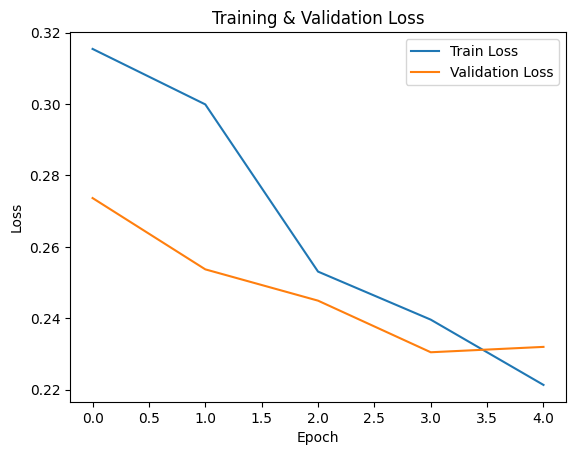

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


Test Accuracy: 89.91%
              precision    recall  f1-score   support

           0       0.82      0.92      0.87       380
           1       0.89      0.80      0.84       380
           2       1.00      0.98      0.99       380

    accuracy                           0.90      1140
   macro avg       0.90      0.90      0.90      1140
weighted avg       0.90      0.90      0.90      1140



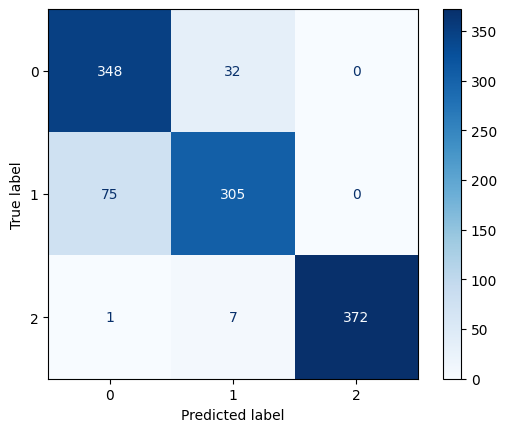

In [ ]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.numpy())

# Accuracy
accuracy = 100 * np.mean(np.array(y_true) == np.array(y_pred))
print(f"Test Accuracy: {accuracy:.2f}%")

# Classification report
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
print(classification_report(y_true, y_pred, target_names=["Z", "O", "S"]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Z", "O", "S"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
